# **PHÂN TÍCH QUY LUẬT TẤN CÔNG THÔNG QUA VIỆC LẠM DỤNG CREDENTIAL**

**Mục tiêu:**
- Phát hiện hành vi lạm dụng credential:
    - brute force
    - credential stuffing
    - password spraying
    - suspicious login automation

## **1. Chuẩn bị vấn đề**

### 1.1. Import các thư viện cần thiết

In [1]:
import gc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import KBinsDiscretizer

from mlxtend.frequent_patterns import (
    fpgrowth,
    association_rules
)

### 1.2. Tải dữ liệu

In [2]:
df = pd.read_parquet(
    "../data_processed/cleaned_data.parquet"
)

df.columns = [
    c.strip().lower()
    for c in df.columns
]


### 1.3. Chọn các features

In [3]:
features = [
    "login_attempts",
    "failed_logins",
    "session_duration",
    "ip_reputation_score",
    "unusual_time_access",
    "protocol_type",
    "browser_type",
    "encryption_used"
]

target = "attack_detected"

df = df[
    features + [target]
].copy()

df = df.fillna(0)

### 1.4. Rời rạc hóa các biến số

In [4]:
numeric_cols = [
    "login_attempts",
    "failed_logins",
    "session_duration",
    "ip_reputation_score"
]

disc = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile"
)

X_disc = disc.fit_transform(
    df[numeric_cols]
)

X_disc = pd.DataFrame(
    X_disc,
    columns=numeric_cols
)


## **3. Thực hiện vấn đề**

### 3.1. Xây dựng transactions

In [5]:
transactions = {}

# NUMERIC FEATURES
for col in X_disc.columns:

    values = X_disc[col].values

    transactions[f"{col}_low"] = (
        values == 0
    ).astype(np.uint8)

    transactions[f"{col}_mid"] = (
        values == 1
    ).astype(np.uint8)

    transactions[f"{col}_high"] = (
        values == 2
    ).astype(np.uint8)

# BOOLEAN FEATURE
transactions["unusual_time_access"] = (
    df["unusual_time_access"]
    .astype(np.uint8)
)

# CATEGORICAL FEATURES
categorical_cols = [
    "protocol_type",
    "browser_type",
    "encryption_used"
]

for col in categorical_cols:

    dummies = pd.get_dummies(
        df[col],
        prefix=col,
        dtype=np.uint8
    )

    for dcol in dummies.columns:
        transactions[dcol] = dummies[dcol].values

# TARGET
transactions["attack_detected"] = (
    df[target]
    .astype(np.uint8)
)

# FINAL TRANSACTION TABLE
transactions = pd.DataFrame(
    transactions,
    dtype=np.uint8
)

print(
    "Transaction shape:",
    transactions.shape
)

Transaction shape: (7571, 24)


### 3.2. Khởi tạo fpgrowth và luật kết hợp

In [6]:
freq_items = fpgrowth(
    transactions.astype(bool),
    min_support=0.03,
    use_colnames=True
)

print(
    "Frequent itemsets:",
    len(freq_items)
)


rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.6
)

print(
    "Generated rules:",
    len(rules)
)

Frequent itemsets: 1268
Generated rules: 877


### 3.3. Xây dựng luật kết hợp

In [7]:

# KEEP ONLY ATTACK RULES
rules = rules[
    rules["consequents"]
    .astype(str)
    .str.contains("attack_detected")
].copy()

# REMOVE SELF TARGET RULES
rules = rules[
    ~rules["antecedents"]
    .astype(str)
    .str.contains("attack_detected")
]

# RULE METRICS
rules["rule_size"] = (
    rules["antecedents"]
    .apply(len)
)

rules["score"] = (
    rules["support"]
    * rules["confidence"]
    * rules["lift"]
)

# SORT RULES
rules = rules.sort_values(
    by=[
        "score",
        "lift",
        "confidence"
    ],
    ascending=False
)

# CREDENTIAL ATTACK FILTER
credential_keywords = [
    "login_attempts",
    "failed_logins",
    "unusual_time_access"
]

def is_credential_rule(x):

    x = str(x)

    return any(
        kw in x
        for kw in credential_keywords
    )

credential_rules = rules[
    rules["antecedents"]
    .apply(is_credential_rule)
].copy()

# STRONG RULES
strong_rules = credential_rules[
    (credential_rules["confidence"] > 0.7)
    &
    (credential_rules["lift"] > 1.4)
    &
    (credential_rules["rule_size"] >= 2)
]

### 3.4. Kiểm tra kết quả

In [8]:
cols = [
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift",
    "score",
    "rule_size"
]

print("TOP CREDENTIAL ATTACK RULES:")
print(
    credential_rules[cols]
    .head(30)
)

print("STRONG CREDENTIAL RULES:")

print(
    strong_rules[cols]
    .head(20)
)


TOP CREDENTIAL ATTACK RULES:
                                           antecedents  \
759  frozenset({login_attempts_high, failed_logins_...   
160  frozenset({failed_logins_high, ip_reputation_s...   
772  frozenset({login_attempts_high, failed_logins_...   
184  frozenset({login_attempts_high, ip_reputation_...   
163  frozenset({protocol_type_TCP, failed_logins_hi...   
762  frozenset({encryption_used_AES, login_attempts...   
175  frozenset({encryption_used_AES, failed_logins_...   
200  frozenset({protocol_type_TCP, login_attempts_h...   
765  frozenset({login_attempts_high, browser_type_C...   
165  frozenset({browser_type_Chrome, failed_logins_...   
77   frozenset({login_attempts_high, failed_logins_...   
196  frozenset({login_attempts_high, failed_logins_...   
764  frozenset({encryption_used_AES, login_attempts...   
187  frozenset({encryption_used_AES, login_attempts...   
384  frozenset({session_duration_high, login_attemp...   
179  frozenset({encryption_used_AES, ip_rep

### 3.5. Biểu diễn luật qua đồ thị

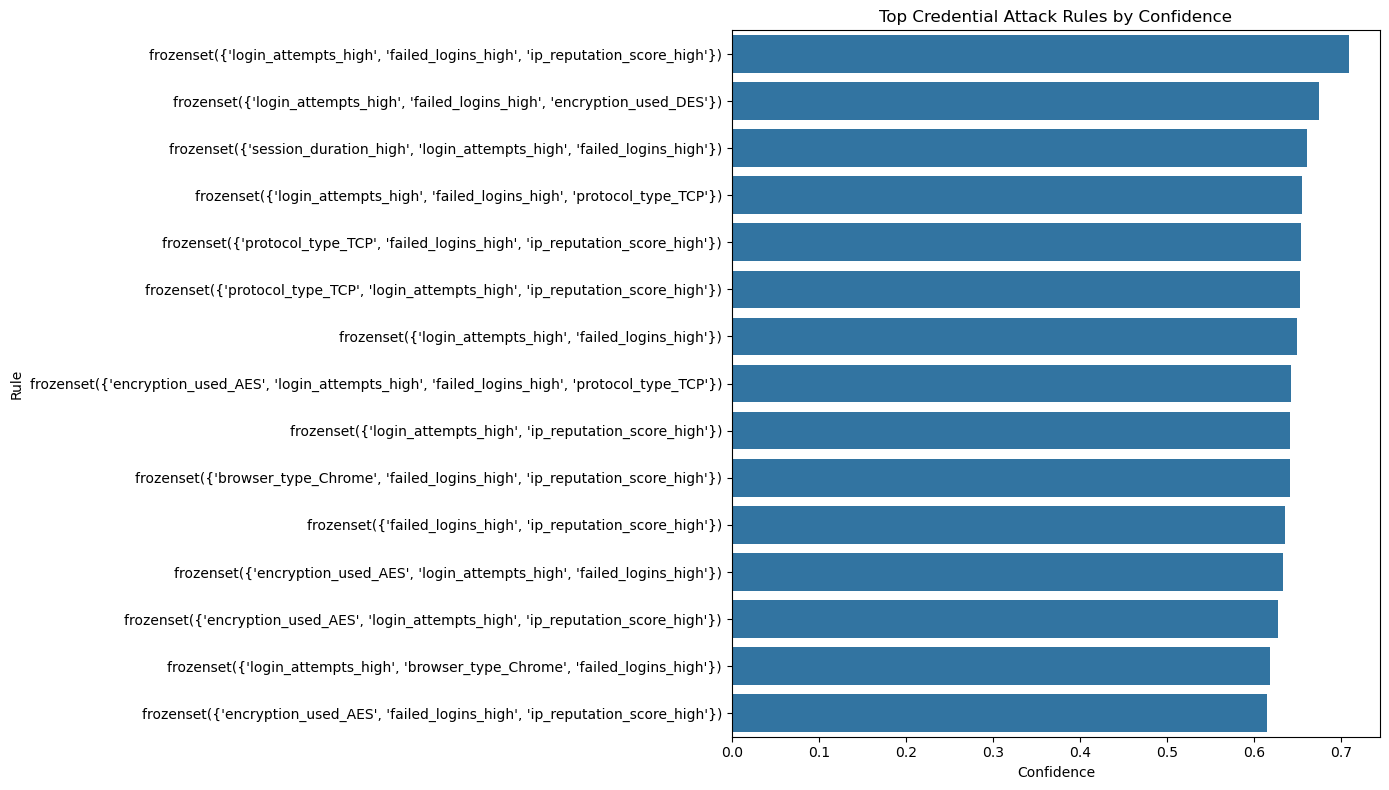

In [13]:
top_plot = credential_rules.head(15).copy().sort_values(by="confidence", ascending=False)

top_plot["rule_name"] = top_plot[
    "antecedents"
].astype(str)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top_plot,
    y="rule_name",
    x="confidence"
)

plt.title(
    "Top Credential Attack Rules by Confidence"
)

plt.xlabel("Confidence")
plt.ylabel("Rule")

plt.tight_layout()

plt.show()


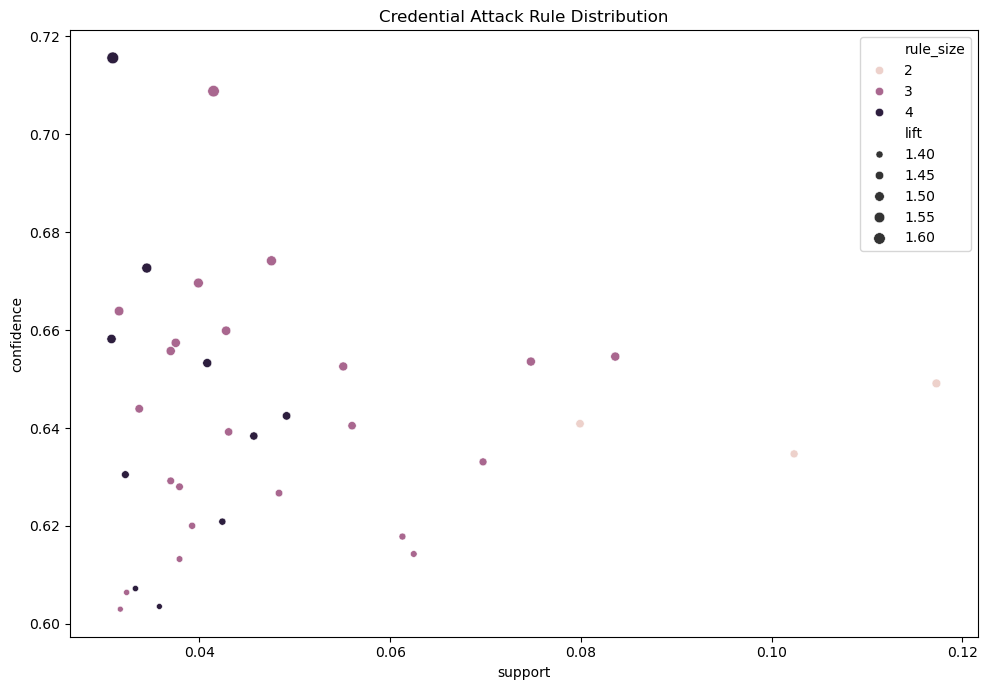

In [10]:

# SUPPORT VS CONFIDENCE
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=credential_rules,
    x="support",
    y="confidence",
    size="lift",
    hue="rule_size"
)

plt.title(
    "Credential Attack Rule Distribution"
)

plt.tight_layout()

plt.show()

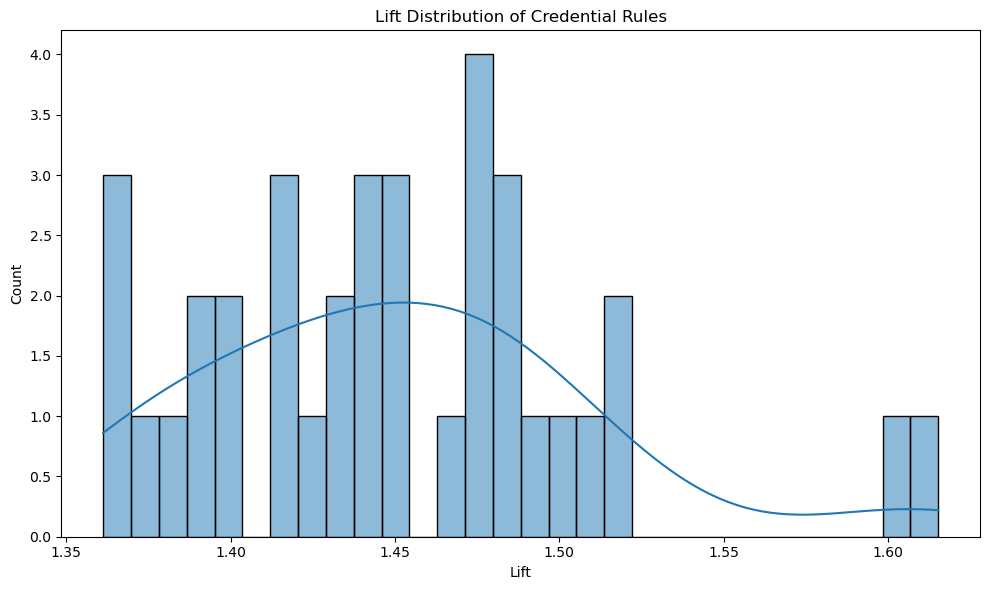

In [11]:
# LIFT DISTRIBUTION
plt.figure(figsize=(10, 6))

sns.histplot(
    credential_rules["lift"],
    bins=30,
    kde=True
)

plt.title(
    "Lift Distribution of Credential Rules"
)

plt.xlabel("Lift")

plt.tight_layout()

plt.show()

# **Kết thúc**